# 1. Import Module


In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle
Draw.DrawingOptions.atomLabelFontFace = "DejaVu Sans"
Draw.DrawingOptions.atomLabelFontSize = 18




Failed to find the pandas get_adjustment() function to patch
Failed to patch pandas - PandasTools will have limited functionality


# 2. Load data

In [2]:
file = "C:/Users/USER-PC/QSAR_Code/Respiratory Irritation/dataset/respiratox_balanced.sdf"
sdfInfo = dict(smilesName='SMILES',molColName='ROMol')
moldf = PandasTools.LoadSDF(file,**sdfInfo)
print(moldf.shape)
moldf = moldf.rename(columns={'ROMol': 'Mol'})
moldf = moldf[pd.notnull(moldf['Mol'])]
print(moldf.shape)
moldf.keys()

[10:50:46] WARNING: not removing hydrogen atom without neighbors
[10:50:46] WARNING: not removing hydrogen atom without neighbors
[10:50:46] WARNING: not removing hydrogen atom without neighbors
[10:50:46] WARNING: not removing hydrogen atom without neighbors
[10:50:46] WARNING: not removing hydrogen atom without neighbors
[10:50:46] WARNING: not removing hydrogen atom without neighbors
[10:50:46] WARNING: not removing hydrogen atom without neighbors
[10:50:46] WARNING: not removing hydrogen atom without neighbors
[10:50:46] WARNING: not removing hydrogen atom without neighbors
[10:50:46] WARNING: not removing hydrogen atom without neighbors
[10:50:46] WARNING: not removing hydrogen atom without neighbors
[10:50:46] WARNING: not removing hydrogen atom without neighbors
[10:50:46] WARNING: not removing hydrogen atom without neighbors
[10:50:46] WARNING: not removing hydrogen atom without neighbors
[10:50:46] WARNING: not removing hydrogen atom without neighbors
[10:50:46] WARNING: not r

(3667, 5)
(3667, 5)


Index(['name', 'Outcome', 'SMILES', 'ID', 'Mol'], dtype='object')

In [3]:
moldf = moldf.rename(columns={'Outcome': 'Outcome'})

In [4]:
moldf.head(1)

,name,Outcome,SMILES,ID,Mol
0,formaldehyde,1,C=O,,<rdkit.Chem.rdchem.Mol object at 0x000002397C3...


In [5]:
moldf= moldf.sort_values(['Outcome'], ascending=True)
moldf['RowID'] = moldf.index
moldf.head(100)

,name,Outcome,SMILES,ID,Mol,RowID
1833,"1,1,1,2,2,3,3,4,4,5,5,6,6,7,7,8,8,8-octadecafl...",0,FC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F...,,<rdkit.Chem.rdchem.Mol object at 0x000002397D5...,1833
2438,"2-ethyl-2-(hydroxymethyl)propane-1,3-diol",0,CCC(CO)(CO)CO,,<rdkit.Chem.rdchem.Mol object at 0x000002397E5...,2438
2439,disodium;2-hexadecyl-3-(2-sulfophenoxy)benzene...,0,CCCCCCCCCCCCCCCCc1c(Oc2ccccc2S(=O)(=O)O)cccc1S...,,<rdkit.Chem.rdchem.Mol object at 0x000002397E5...,2439
2440,2-[4-[bis(2-hydroxyethyl)amino]-2-nitroanilino...,0,O=[N+]([O-])c1cc(N(CCO)CCO)ccc1NCCO,,<rdkit.Chem.rdchem.Mol object at 0x000002397E5...,2440
2441,ethyl N-phenylcarbamate,0,CCOC(=O)Nc1ccccc1,,<rdkit.Chem.rdchem.Mol object at 0x000002397E5...,2441
...,...,...,...,...,...,...
2475,N-[(4-tert-butylphenyl)methyl]-4-chloro-5-ethy...,0,CCc1nn(C)c(C(=O)NCc2ccc(C(C)(C)C)cc2)c1Cl,,<rdkit.Chem.rdchem.Mol object at 0x000002397E5...,2475
2476,(Z)-2-fluoro-3-morpholin-4-ylprop-2-enal,0,O=CC(F)=CN1CCOCC1,,<rdkit.Chem.rdchem.Mol object at 0x000002397E5...,2476
2477,butane-1-thiol,0,CCCCS,,<rdkit.Chem.rdchem.Mol object at 0x000002397E5...,2477
2478,"1,1,1,3,3,3-hexafluoro-2-(fluoromethoxy)propane",0,FCOC(C(F)(F)F)C(F)(F)F,,<rdkit.Chem.rdchem.Mol object at 0x000002397E5...,2478


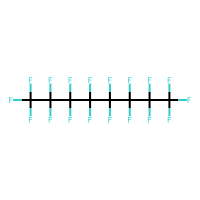

FC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F


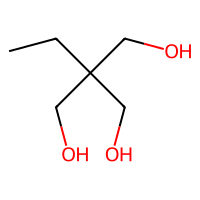

CCC(CO)(CO)CO


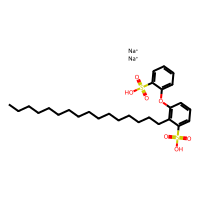

CCCCCCCCCCCCCCCCc1c(Oc2ccccc2S(=O)(=O)O)cccc1S(=O)(=O)O.[Na+].[Na+]


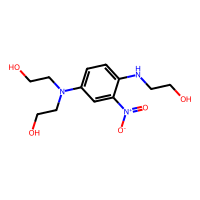

O=[N+]([O-])c1cc(N(CCO)CCO)ccc1NCCO


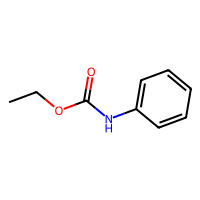

CCOC(=O)Nc1ccccc1


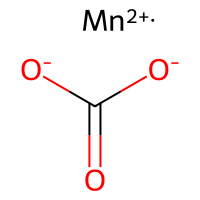

O=C([O-])[O-].[Mn+2]


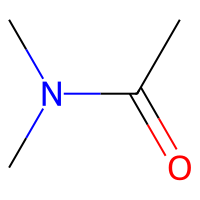

CC(=O)N(C)C


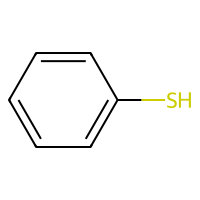

Sc1ccccc1


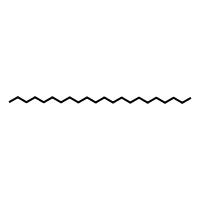

CCCCCCCCCCCCCCCCCCCCCC


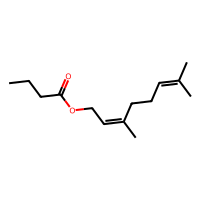

CCCC(=O)OCC=C(C)CCC=C(C)C


In [6]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

def display_molecules_in_column(moldf, num_mols):
    for _, row in moldf.head(num_mols).iterrows():
        smi = row['SMILES']
        if smi is not None:
            mol = Chem.MolFromSmiles(smi)  # Create Mol object from SMILES
            if mol is not None:
                img = Draw.MolToImage(mol, size=(200, 200))
                display(img)
                print(smi)  

display_molecules_in_column(moldf, 10)


In [7]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from mordred import Calculator, descriptors
from fancyimpute import KNN


(CVXPY) Sep 13 10:51:21 AM: Encountered unexpected exception importing solver CVXOPT:
ImportError('DLL load failed while importing base: The specified module could not be found.')
(CVXPY) Sep 13 10:51:21 AM: Encountered unexpected exception importing solver GLPK:
ImportError('DLL load failed while importing base: The specified module could not be found.')
(CVXPY) Sep 13 10:51:21 AM: Encountered unexpected exception importing solver GLPK_MI:
ImportError('DLL load failed while importing base: The specified module could not be found.')


## 3. Morgan, MACCsKeys, Modred

In [8]:
# Morgan fingerprints
nBits = 1024
radius = 2
useFeatures = False
moldf['Morgan_Descriptors'] = moldf['Mol'].apply(lambda mol: AllChem.GetMorganFingerprintAsBitVect(mol, nBits=nBits, radius=radius, useFeatures=useFeatures))

# MACCS keys
moldf['MACCS_Descriptors'] = moldf['Mol'].apply(lambda mol: MACCSkeys.GenMACCSKeys(mol))



In [9]:
from sklearn.preprocessing import StandardScaler
from rdkit import Chem
from mordred import Calculator, descriptors

# create descriptor calculator with all descriptors
calc = Calculator(descriptors, ignore_3D=True)
df = calc.pandas(moldf['Mol'])

  2%|▏         | 75/3667 [00:03<01:31, 39.25it/s] 

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


  3%|▎         | 115/3667 [00:04<01:16, 46.23it/s]

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


  5%|▍         | 169/3667 [00:04<00:42, 82.30it/s]

...

 13%|█▎        | 482/3667 [00:08<00:38, 81.68it/s]

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 16%|█▌        | 591/3667 [00:09<00:28, 108.74it/s]

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 24%|██▎       | 869/3667 [00:13<00:29, 95.68it/s] [10:51:41] WARNING: not removing hydrogen atom without neighbors
[10:51:41] WARNING: not removing hydrogen atom without neighbors
[10:51:41] WARNING: not removing hydrogen atom without neighbors
[10:51:41] WARNING: not removing hydrogen atom without neighbors
 25%|██▍       | 906/3667 [00:15<00:53, 51.93it/s][10:51:42] WARNING: not removing hydrogen atom without neighbors
[10:51:42] WARNING: not removing hydrogen atom without neighbors
[10:51:42] WARNING: not removing hydrogen atom without neighbors
[10:51:42] WARNING: not removing hydrogen atom without neighbors
 38%|███▊      | 1376/3667 [00:21<00:56, 40.72it/s][10:51:49] WARNING: not removing hydrogen atom without neighbors
[10:51:49] WARNING: not removing hydrogen atom without neighbors
 79%|███████▉  | 2907/3667 [00:38<00:06, 111.71it/s][10:52:06] WARNING: not removing hydrogen atom without neighbors
[10:52:06] WARNING: not removing hydrogen atom without neighbors
[10:52:06] WARNI

In [10]:
from fancyimpute import KNN
import pandas as pd
import numpy as np

df_numeric = df.select_dtypes(include=[float]) 

df_filled = pd.DataFrame(KNN(k=3).fit_transform(df_numeric), columns=df_numeric.columns, index=df_numeric.index)


Imputing row 1/3667 with 0 missing, elapsed time: 13.957
Imputing row 101/3667 with 0 missing, elapsed time: 13.958
Imputing row 201/3667 with 0 missing, elapsed time: 13.958
Imputing row 301/3667 with 0 missing, elapsed time: 13.958
Imputing row 401/3667 with 0 missing, elapsed time: 13.958
Imputing row 501/3667 with 0 missing, elapsed time: 13.959
Imputing row 601/3667 with 0 missing, elapsed time: 13.959
Imputing row 701/3667 with 0 missing, elapsed time: 13.959
Imputing row 801/3667 with 0 missing, elapsed time: 13.959
Imputing row 901/3667 with 0 missing, elapsed time: 13.960
Imputing row 1001/3667 with 0 missing, elapsed time: 13.960
Imputing row 1101/3667 with 0 missing, elapsed time: 13.960
Imputing row 1201/3667 with 0 missing, elapsed time: 13.960
Imputing row 1301/3667 with 0 missing, elapsed time: 13.961
Imputing row 1401/3667 with 0 missing, elapsed time: 13.961
Imputing row 1501/3667 with 0 missing, elapsed time: 13.961
Imputing row 1601/3667 with 0 missing, elapsed time:

In [11]:
X = np.array(df_filled)
scaler = StandardScaler()
x=  scaler.fit_transform(X)
moldf['Modred_Descriptor'] = x.tolist()

In [12]:
print(x.shape)

(3667, 397)


In [13]:
moldf

,name,Outcome,SMILES,ID,Mol,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor
1833,"1,1,1,2,2,3,3,4,4,5,5,6,6,7,7,8,8,8-octadecafl...",0,FC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F...,,<rdkit.Chem.rdchem.Mol object at 0x000002397D5...,1833,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[3.074015942038643, 2.014206346374641, 3.32094..."
2438,"2-ethyl-2-(hydroxymethyl)propane-1,3-diol",0,CCC(CO)(CO)CO,,<rdkit.Chem.rdchem.Mol object at 0x000002397E5...,2438,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4338349091955931, -0.4594031474353171, -0...."
2439,disodium;2-hexadecyl-3-(2-sulfophenoxy)benzene...,0,CCCCCCCCCCCCCCCCc1c(Oc2ccccc2S(=O)(=O)O)cccc1S...,,<rdkit.Chem.rdchem.Mol object at 0x000002397E5...,2439,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.8374261408575139, 0.5219745321740685, 1.023..."
2440,2-[4-[bis(2-hydroxyethyl)amino]-2-nitroanilino...,0,O=[N+]([O-])c1cc(N(CCO)CCO)ccc1NCCO,,<rdkit.Chem.rdchem.Mol object at 0x000002397E5...,2440,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.37507083033513977, 0.3606521738821147, 0.19..."
2441,ethyl N-phenylcarbamate,0,CCOC(=O)Nc1ccccc1,,<rdkit.Chem.rdchem.Mol object at 0x000002397E5...,2441,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.19271877529700926, -0.05609725170543264, -..."
...,...,...,...,...,...,...,...,...,...
1217,dipotassium;sulfonatooxy sulfate,1,O=S(=O)([O-])OOS(=O)(=O)[O-].[K+].[K+],,<rdkit.Chem.rdchem.Mol object at 0x000002397D4...,1217,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.37074975266670646, -0.4355035387994722, 0.5..."
1218,diazanium;sulfonatooxy sulfate,1,O=S(=O)([O-])OOS(=O)(=O)[O-].[NH4+].[NH4+],,<rdkit.Chem.rdchem.Mol object at 0x000002397D4...,1218,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.37074975266670646, -0.4355035387994722, 0.5..."
1219,zinc;sulfate,1,O=S(=O)([O-])[O-].[Zn+2],,<rdkit.Chem.rdchem.Mol object at 0x000002397D4...,1219,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[-0.19099034422963584, -0.6685247229989609, -0..."
1193,tetrachlorostannane,1,Cl[Sn](Cl)(Cl)Cl,,<rdkit.Chem.rdchem.Mol object at 0x000002397D4...,1193,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8444025839815338, -0.7449592120991542, -0...."


In [15]:
data = moldf

In [16]:
data 

,name,Outcome,SMILES,ID,Mol,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor
1833,"1,1,1,2,2,3,3,4,4,5,5,6,6,7,7,8,8,8-octadecafl...",0,FC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F...,,<rdkit.Chem.rdchem.Mol object at 0x000002397D5...,1833,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[3.074015942038643, 2.014206346374641, 3.32094..."
2438,"2-ethyl-2-(hydroxymethyl)propane-1,3-diol",0,CCC(CO)(CO)CO,,<rdkit.Chem.rdchem.Mol object at 0x000002397E5...,2438,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4338349091955931, -0.4594031474353171, -0...."
2439,disodium;2-hexadecyl-3-(2-sulfophenoxy)benzene...,0,CCCCCCCCCCCCCCCCc1c(Oc2ccccc2S(=O)(=O)O)cccc1S...,,<rdkit.Chem.rdchem.Mol object at 0x000002397E5...,2439,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.8374261408575139, 0.5219745321740685, 1.023..."
2440,2-[4-[bis(2-hydroxyethyl)amino]-2-nitroanilino...,0,O=[N+]([O-])c1cc(N(CCO)CCO)ccc1NCCO,,<rdkit.Chem.rdchem.Mol object at 0x000002397E5...,2440,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.37507083033513977, 0.3606521738821147, 0.19..."
2441,ethyl N-phenylcarbamate,0,CCOC(=O)Nc1ccccc1,,<rdkit.Chem.rdchem.Mol object at 0x000002397E5...,2441,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.19271877529700926, -0.05609725170543264, -..."
...,...,...,...,...,...,...,...,...,...
1217,dipotassium;sulfonatooxy sulfate,1,O=S(=O)([O-])OOS(=O)(=O)[O-].[K+].[K+],,<rdkit.Chem.rdchem.Mol object at 0x000002397D4...,1217,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.37074975266670646, -0.4355035387994722, 0.5..."
1218,diazanium;sulfonatooxy sulfate,1,O=S(=O)([O-])OOS(=O)(=O)[O-].[NH4+].[NH4+],,<rdkit.Chem.rdchem.Mol object at 0x000002397D4...,1218,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.37074975266670646, -0.4355035387994722, 0.5..."
1219,zinc;sulfate,1,O=S(=O)([O-])[O-].[Zn+2],,<rdkit.Chem.rdchem.Mol object at 0x000002397D4...,1219,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[-0.19099034422963584, -0.6685247229989609, -0..."
1193,tetrachlorostannane,1,Cl[Sn](Cl)(Cl)Cl,,<rdkit.Chem.rdchem.Mol object at 0x000002397D4...,1193,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8444025839815338, -0.7449592120991542, -0...."


# 4. Split into Train and Test Data and Save into sdf file

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect



# Remove duplicate columns
data = moldf.loc[:, ~data.columns.duplicated()]

# Split the data into train and test sets
train, test = train_test_split(data, test_size=0.2, random_state=42)

# Function to convert bit vectors to a list of integers
def bitvector_to_list(bitvector):
    if isinstance(bitvector, ExplicitBitVect):
        return list(map(int, bitvector.ToBitString()))
    else:
        return bitvector

# Convert bit vectors to lists before saving
def convert_bit_vectors(df):
    if 'Morgan_Descriptors' in df.columns:
        df['Morgan_Descriptors'] = df['Morgan_Descriptors'].apply(bitvector_to_list)
    if 'MACCS_Descriptors' in df.columns:
        df['MACCS_Descriptors'] = df['MACCS_Descriptors'].apply(bitvector_to_list)
    return df

# Convert bit vectors for train and test sets
train = convert_bit_vectors(train)
test = convert_bit_vectors(test)

# Function to save DataFrame to SDF
def save_to_sdf(df, filename):
    sdf_writer = Chem.SDWriter(filename)
    for idx, row in df.iterrows():
        mol = Chem.MolFromSmiles(row['SMILES'])
        if mol is not None:
            mol.SetProp("_Name", str(idx))
            for col in df.columns:
                if col != 'Mol' and col != 'SMILES':
                    mol.SetProp(col, str(row[col]))
            sdf_writer.write(mol)
    sdf_writer.close()


# Save the train and test sets to SDF files
save_to_sdf(train, 'C:/Users/USER-PC/QSAR_Code/Respiratory Irritation/dataset/train_set_respiratory_irritation_features.sdf')
save_to_sdf(test, 'C:/Users/USER-PC/QSAR_Code/Respiratory Irritation/dataset/test_set_respiratory_irritatio_features.sdf')

print("Train and test sets saved to 'train_set.sdf' and 'test_set.sdf' respectively.")


[10:52:50] WARNING: not removing hydrogen atom without neighbors
[10:52:50] WARNING: not removing hydrogen atom without neighbors
[10:52:51] WARNING: not removing hydrogen atom without neighbors
[10:52:51] WARNING: not removing hydrogen atom without neighbors
[10:52:51] WARNING: not removing hydrogen atom without neighbors
[10:52:51] WARNING: not removing hydrogen atom without neighbors
[10:52:51] WARNING: not removing hydrogen atom without neighbors
[10:52:52] WARNING: not removing hydrogen atom without neighbors
[10:52:52] WARNING: not removing hydrogen atom without neighbors
[10:52:52] WARNING: not removing hydrogen atom without neighbors
[10:52:52] WARNING: not removing hydrogen atom without neighbors
[10:52:52] WARNING: not removing hydrogen atom without neighbors
[10:52:52] WARNING: not removing hydrogen atom without neighbors
[10:52:52] WARNING: not removing hydrogen atom without neighbors
[10:52:53] WARNING: not removing hydrogen atom without neighbors
[10:52:53] WARNING: not r

Train and test sets saved to 'train_set.sdf' and 'test_set.sdf' respectively.


In [18]:
test

,name,Outcome,SMILES,ID,Mol,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor
568,N-methylmethanamine,1,CNC,,<rdkit.Chem.rdchem.Mol object at 0x000002397C4...,568,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7838422003386987, -0.7103490381116897, -0...."
1653,dimethoxy-(2-methylpropyl)-propan-2-ylsilane,1,CO[Si](CC(C)C)(OC)C(C)C,,<rdkit.Chem.rdchem.Mol object at 0x000002397D5...,1653,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4641784768228143, -0.5779053735880487, -0...."
1343,cerium(4+);disulfate;tetrahydrate,1,O.O.O.O.O=S(=O)([O-])[O-].O=S(=O)([O-])[O-].[C...,,<rdkit.Chem.rdchem.Mol object at 0x000002397D4...,1343,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.720757043809812, -0.5908509949324647, 0.631..."
3312,"4,5,6,7-tetrachloro-3-[4-[(4,5,6,7-tetrachloro...",0,O=C1NC(=Nc2ccc(N=C3NC(=O)c4c(Cl)c(Cl)c(Cl)c(Cl...,,<rdkit.Chem.rdchem.Mol object at 0x000002397F6...,3312,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0239046482374619, 1.6686578381813821, 1.407..."
1466,2-ethylhexyl carbonochloridate,1,CCCCC(CC)COC(=O)Cl,,<rdkit.Chem.rdchem.Mol object at 0x000002397D4...,1466,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.3887036535475109, -0.3289511169646631, -0...."
...,...,...,...,...,...,...,...,...,...
417,ethoxyethane;trifluoroborane,1,CCOCC.FB(F)F,,<rdkit.Chem.rdchem.Mol object at 0x000002397C4...,417,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.06827173844612727, -0.3384113787163518, -0..."
877,"11-methoxy-6,8,16,20-tetraoxapentacyclo[10.8.0...",1,COc1cc2c(c3oc(=O)c4c(c13)CCOC4=O)C1C=COC1O2,,<rdkit.Chem.rdchem.Mol object at 0x000002397D4...,877,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.896192797148208, 1.2389627912494188, 1.2104..."
2095,2-ethoxy-N'-hydroxybenzenecarboximidamide,0,CCOc1ccccc1C(N)=NO,,<rdkit.Chem.rdchem.Mol object at 0x000002397D5...,2095,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.13827319667474838, 0.051450987155869904, -..."
1585,"4,5-dichloro-2-octyl-1,2-thiazol-3-one",1,CCCCCCCCn1sc(Cl)c(Cl)c1=O,,<rdkit.Chem.rdchem.Mol object at 0x000002397D5...,1585,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.3107322076193348, -0.18953673325556725, -0..."


In [19]:
# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the train and test sets from SDF files
train_df = load_sdf_to_df('C:/Users/USER-PC/QSAR_Code/Respiratory Irritation/dataset/train_set_respiratory_irritation_features.sdf')
test_df = load_sdf_to_df('C:/Users/USER-PC/QSAR_Code/Respiratory Irritation/dataset/test_set_respiratory_irritatio_features.sdf')

# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

print("Train DataFrame:")
print(train_df.head())

print("Test DataFrame:")
print(test_df.head())


[10:53:01] WARNING: not removing hydrogen atom without neighbors
[10:53:01] WARNING: not removing hydrogen atom without neighbors
[10:53:01] WARNING: not removing hydrogen atom without neighbors
[10:53:01] WARNING: not removing hydrogen atom without neighbors
[10:53:01] WARNING: not removing hydrogen atom without neighbors
[10:53:01] WARNING: not removing hydrogen atom without neighbors
[10:53:02] WARNING: not removing hydrogen atom without neighbors
[10:53:02] WARNING: not removing hydrogen atom without neighbors
[10:53:02] WARNING: not removing hydrogen atom without neighbors
[10:53:02] WARNING: not removing hydrogen atom without neighbors
[10:53:02] WARNING: not removing hydrogen atom without neighbors
[10:53:02] WARNING: not removing hydrogen atom without neighbors
[10:53:02] WARNING: not removing hydrogen atom without neighbors
[10:53:02] WARNING: not removing hydrogen atom without neighbors
[10:53:02] WARNING: not removing hydrogen atom without neighbors
[10:53:02] WARNING: not r

Train DataFrame:
                                                name Outcome ID RowID  \
0  2-[2-[3-(carboxymethyl)-4-oxo-2-sulfanylidene-...       0     1832   
1                                     propyl nitrate       1      773   
2  dipotassium;5-[[4-anilino-6-[bis(2-hydroxyethy...       0     2998   
3                                           methanol       1       42   
4                           nickel(2+);diperchlorate       1     1760   

                                  Morgan_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [20]:
train_df

,name,Outcome,ID,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES
0,2-[2-[3-(carboxymethyl)-4-oxo-2-sulfanylidene-...,0,,1832,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.175334414529006, 1.4122349538592949, 1.0856...",CCN1C(=CC(C)=c2sc(=C3SC(=S)N(CC(=O)O)C3=O)n(CC...
1,propyl nitrate,1,,773,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.2860540529351707, -0.32496784885868896, -0...",CCCO[N+](=O)[O-]
2,dipotassium;5-[[4-anilino-6-[bis(2-hydroxyethy...,0,,2998,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[3.1319183827956505, 2.989609123825066, 3.3086...",O=S(=O)([O-])c1cc(Nc2nc(Nc3ccccc3)nc(N(CCO)CCO...
3,methanol,1,,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7527304411259781, -0.7237925679693525, -0....",CO
4,nickel(2+);diperchlorate,1,,1760,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.673030151195501, -0.6346669440981806, 0.848...",[Ni+2].[O-][Cl+3]([O-])([O-])[O-].[O-][Cl+3]([...
...,...,...,...,...,...,...,...,...
2928,2-methylpropan-1-olate;titanium(4+),0,,3280,"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.14173263623973606, -0.28015608266647957, -0...",CC(C)C[O-].CC(C)C[O-].CC(C)C[O-].CC(C)C[O-].[T...
2929,2-(1-propoxyethoxy)ethylbenzene,0,,3445,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.23160847431290987, -0.11435254775530485, -...",CCCOC(C)OCCc1ccccc1
2930,N-cyclohexylcyclohexanamine;nitrous acid,0,,2150,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.23160847431290987, -0.14123960747063047, -...",C1CCC(NC2CCCCC2)CC1.O=NO
2931,strontium;oxoarsinite;tetrahydrate,1,,1347,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0.05644203159416418, -0.7246224154914306, -0....",O.O.O.O.O=[As][O-].O=[As][O-].[Sr+2]


In [21]:
train

,name,Outcome,SMILES,ID,Mol,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor
1832,2-[2-[3-(carboxymethyl)-4-oxo-2-sulfanylidene-...,0,CCN1C(=CC(C)=c2sc(=C3SC(=S)N(CC(=O)O)C3=O)n(CC...,,<rdkit.Chem.rdchem.Mol object at 0x000002397D5...,1832,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.175334414529006, 1.4122349538592949, 1.0856..."
773,propyl nitrate,1,CCCO[N+](=O)[O-],,<rdkit.Chem.rdchem.Mol object at 0x000002397C4...,773,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.2860540529351707, -0.32496784885868896, -0..."
2998,dipotassium;5-[[4-anilino-6-[bis(2-hydroxyethy...,0,O=S(=O)([O-])c1cc(Nc2nc(Nc3ccccc3)nc(N(CCO)CCO...,,<rdkit.Chem.rdchem.Mol object at 0x000002397E6...,2998,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[3.1319183827956505, 2.989609123825066, 3.3086..."
42,methanol,1,CO,,<rdkit.Chem.rdchem.Mol object at 0x000002397C4...,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7527304411259781, -0.7237925679693525, -0...."
1760,nickel(2+);diperchlorate,1,[Ni+2].[O-][Cl+3]([O-])([O-])[O-].[O-][Cl+3]([...,,<rdkit.Chem.rdchem.Mol object at 0x000002397D5...,1760,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.673030151195501, -0.6346669440981806, 0.848..."
...,...,...,...,...,...,...,...,...,...
3280,2-methylpropan-1-olate;titanium(4+),0,CC(C)C[O-].CC(C)C[O-].CC(C)C[O-].CC(C)C[O-].[T...,,<rdkit.Chem.rdchem.Mol object at 0x000002397F6...,3280,"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.14173263623973606, -0.28015608266647957, -0..."
3445,2-(1-propoxyethoxy)ethylbenzene,0,CCCOC(C)OCCc1ccccc1,,<rdkit.Chem.rdchem.Mol object at 0x000002397F6...,3445,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.23160847431290987, -0.11435254775530485, -..."
2150,N-cyclohexylcyclohexanamine;nitrous acid,0,C1CCC(NC2CCCCC2)CC1.O=NO,,<rdkit.Chem.rdchem.Mol object at 0x000002397E5...,2150,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.23160847431290987, -0.14123960747063047, -..."
1347,strontium;oxoarsinite;tetrahydrate,1,O.O.O.O.O=[As][O-].O=[As][O-].[Sr+2],,<rdkit.Chem.rdchem.Mol object at 0x000002397D4...,1347,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0.05644203159416418, -0.7246224154914306, -0...."


In [27]:
train

,Outcome,SMILES,Mol,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor
1608,0,CC(O)CO,<rdkit.Chem.rdchem.Mol object at 0x00000144073...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0858958172735298, -1.372566035884163, -1.3..."
617,1,CCCCCCCCCCCC[N+](C)(C)CCCS(=O)(=O)O,<rdkit.Chem.rdchem.Mol object at 0x00000144062...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.5078503976983185, 0.05839121285330338, 0.10..."
13,1,CCC1(CO)COCOC1,<rdkit.Chem.rdchem.Mol object at 0x00000144061...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.47515459257872156, 0.39000886268962404, 0...."
368,1,C=CCCCCCCCC,<rdkit.Chem.rdchem.Mol object at 0x00000144061...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5364250449069771, -1.0993449477973771, -1...."
838,1,CC(O)CCO,<rdkit.Chem.rdchem.Mol object at 0x00000144062...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0111170801950289, -1.1640682089309673, -1...."
...,...,...,...,...,...,...
1645,0,OCCCOCC(COCCCO)(COCCCO)COCCCO,<rdkit.Chem.rdchem.Mol object at 0x00000144073...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.9718916228574594, 0.39553883491703684, 0.45..."
1102,1,O=C(O)c1ccc(O)c(O)c1,<rdkit.Chem.rdchem.Mol object at 0x00000144063...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4479577103546899, 0.3332568814599739, 0.39..."
1137,1,CCC(C)=O,<rdkit.Chem.rdchem.Mol object at 0x00000144063...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0858958172735298, -1.372566035884162, -1.3..."
1301,0,CCCCCCCCCCCCCC(=O)OC,<rdkit.Chem.rdchem.Mol object at 0x00000144073...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.16152685598990882, -0.7174480082943241, -0...."
